In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df = pd.read_csv('C:\\Users\\HP\\Downloads\\E9G5M5BlR9mtLQHhRfAq_AirPassengers - hart demerchant - AirPassengers - hart demerchant.csv')

In [4]:
df.head(10)

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [6]:
df['Month'] = pd.to_datetime(df['Month'])

df.set_index('Month', inplace=True)

In [7]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


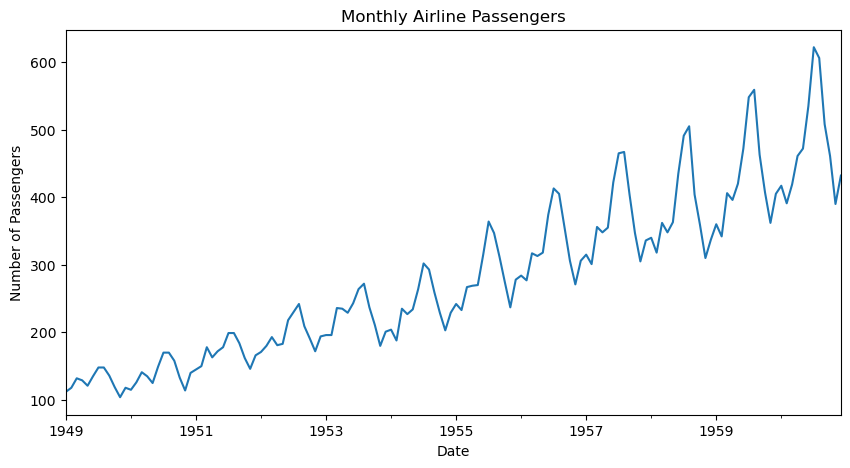

In [9]:
df['#Passengers'].plot(title="Monthly Airline Passengers", figsize=(10,5))
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.show()

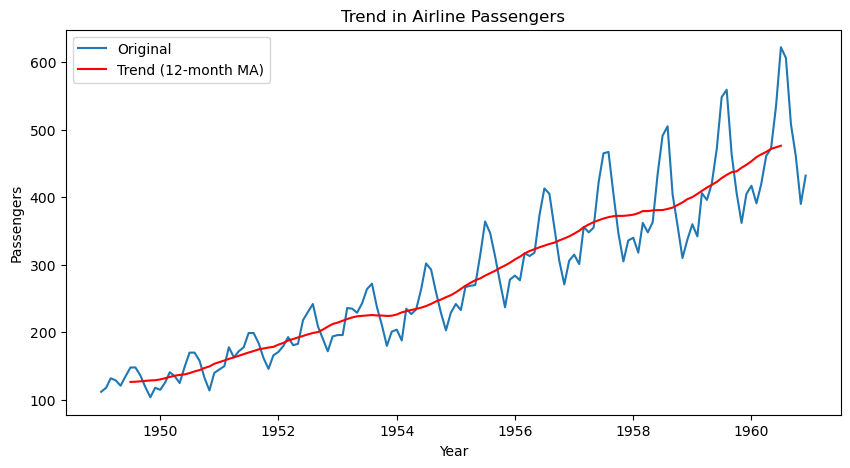

In [10]:
df['Trend'] = df['#Passengers'].rolling(window=12, center=True).mean()

plt.figure(figsize=(10,5))
plt.plot(df['#Passengers'], label='Original')
plt.plot(df['Trend'], label='Trend (12-month MA)', color='red')
plt.title("Trend in Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

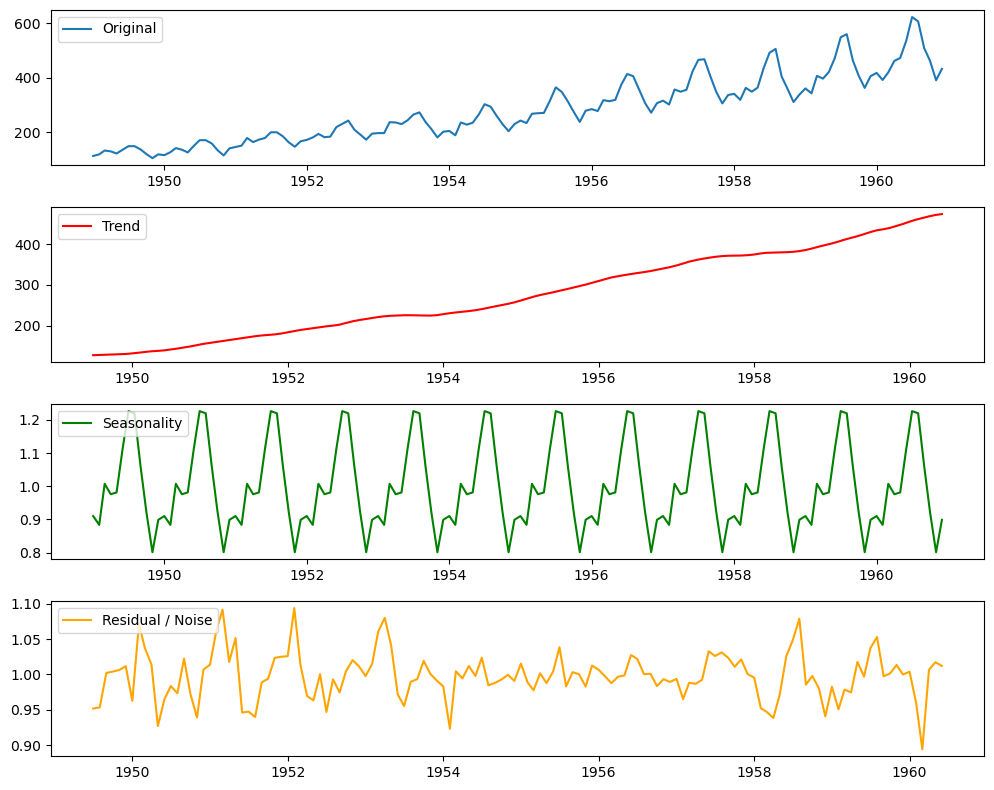

In [11]:
decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.plot(df['#Passengers'], label='Original')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Trend', color='red')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual / Noise', color='orange')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['#Passengers'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary")

ADF Statistic: 0.8153688792060597
p-value: 0.9918802434376411
The series is likely non-stationary


In [13]:
print(result)

(0.8153688792060597, 0.9918802434376411, 13, 130, {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}, 996.692930839019)


In [14]:
 df['Detrended_Ratio'] = df['#Passengers'] / df['Trend']

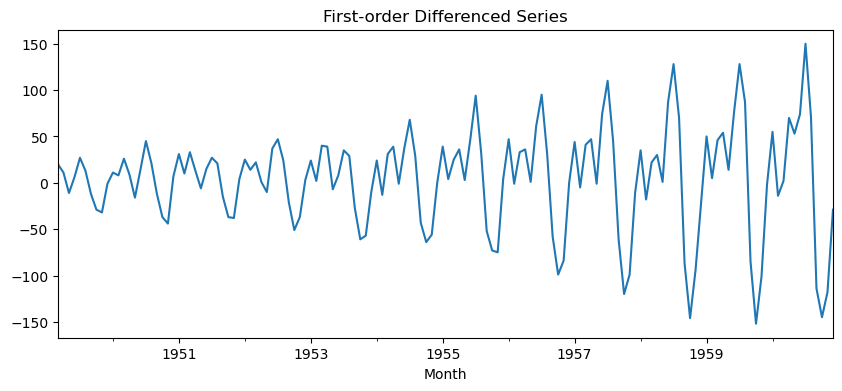

In [15]:
df['Diff_1'] = df['#Passengers'] - df['#Passengers'].shift(2)

#Drop missing values
df_diff = df['Diff_1'].dropna()

df_diff.plot(title="First-order Differenced Series", figsize=(10,4))
plt.show()

In [16]:
result_diff = adfuller(df_diff)

print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])
if result_diff[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary")

ADF Statistic: -2.961695135555423
p-value: 0.038629757676988535
The series is likely stationary


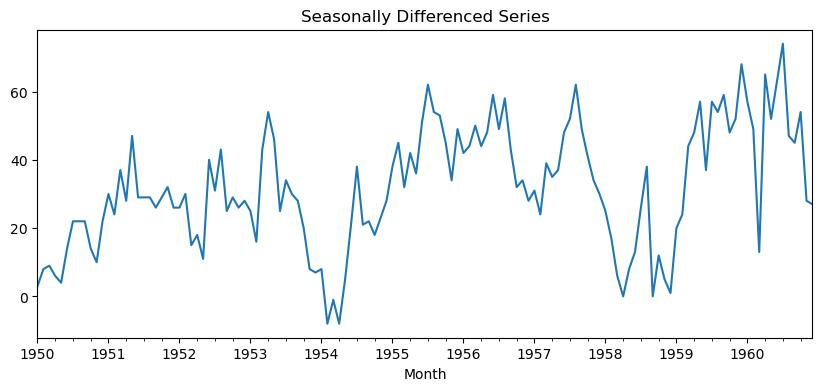

In [17]:
df['Seasonal_Diff'] = df['#Passengers'] - df['#Passengers'].shift(12)
df_seasonal = df['Seasonal_Diff'].dropna()

df_seasonal.plot(title="Seasonally Differenced Series", figsize=(10,4))
plt.show()

In [18]:
result = adfuller(df_seasonal)

print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary")

ADF Statistic: -3.3830207264924805
p-value: 0.011551493085514982
The series is likely stationary


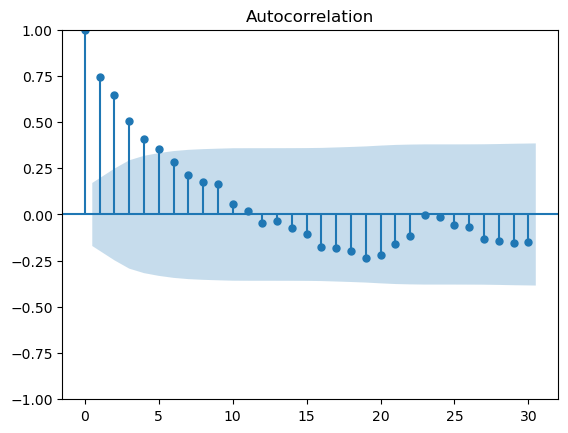

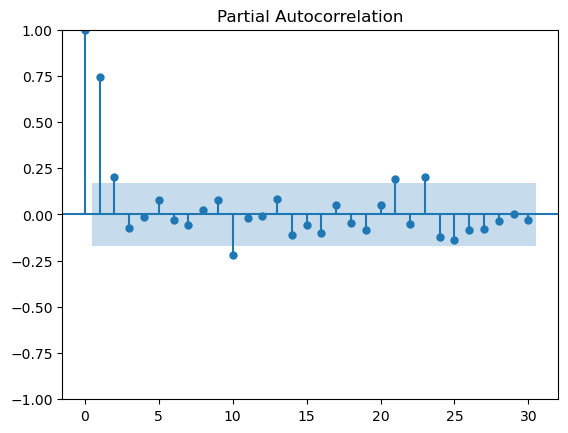

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_seasonal, lags=30)
plt.show()

plot_pacf(df_seasonal, lags=30)
plt.show()

In [20]:
train_size = int(len(df) * 0.8)

train = df['#Passengers'][:train_size]
test = df['#Passengers'][train_size:]

In [21]:
train.tail()

Month
1958-03-01    362
1958-04-01    348
1958-05-01    363
1958-06-01    435
1958-07-01    491
Name: #Passengers, dtype: int64

In [22]:
test.head()

Month
1958-08-01    505
1958-09-01    404
1958-10-01    359
1958-11-01    310
1958-12-01    337
Name: #Passengers, dtype: int64

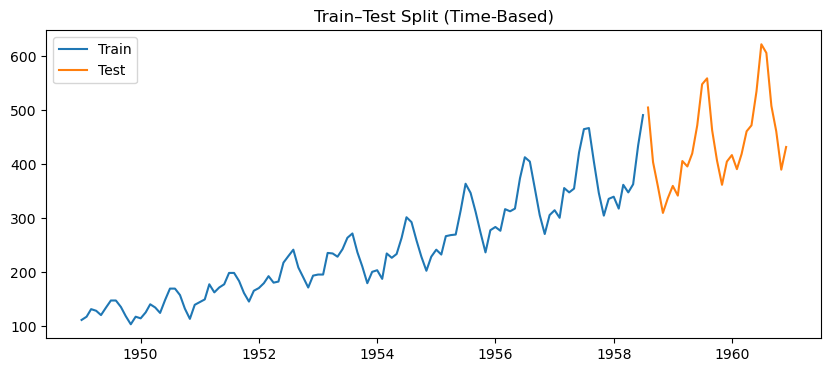

In [23]:
plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.legend()
plt.title("Train–Test Split (Time-Based)")
plt.show()

In [24]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1, 1, 3))
fitted_model = model.fit()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


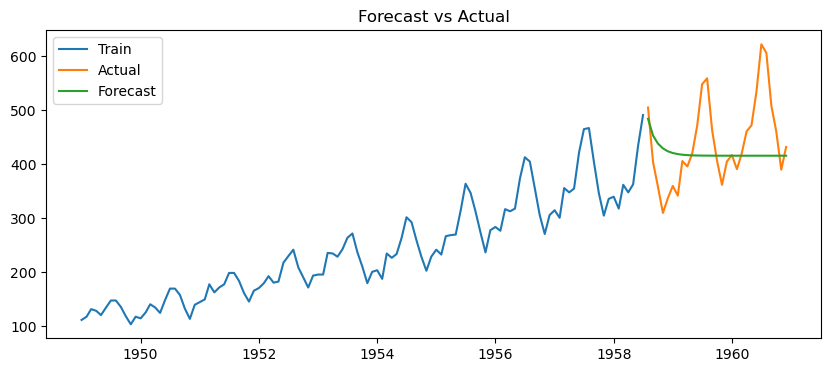

In [25]:
forecast_1 = fitted_model.forecast(steps=len(test))

plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast_1, label='Forecast')
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,1,3),
    seasonal_order=(1,1,3,12)
)

results = model.fit()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [27]:
forecast_2 = results.forecast(steps=len(test))

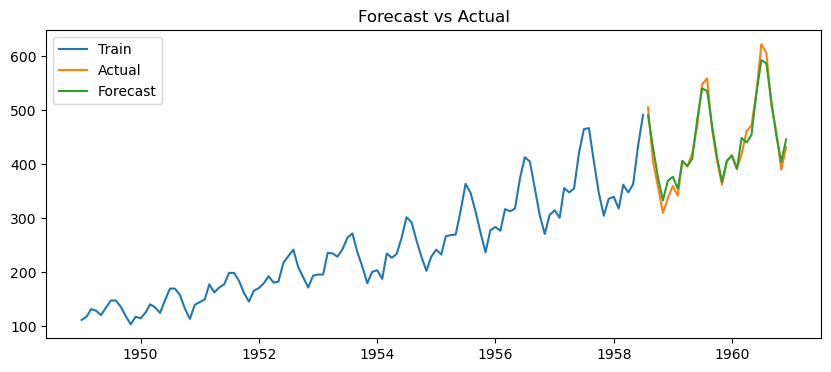

In [28]:
plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast_2, label='Forecast')
plt.legend()
plt.title("Forecast vs Actual")
plt.show()


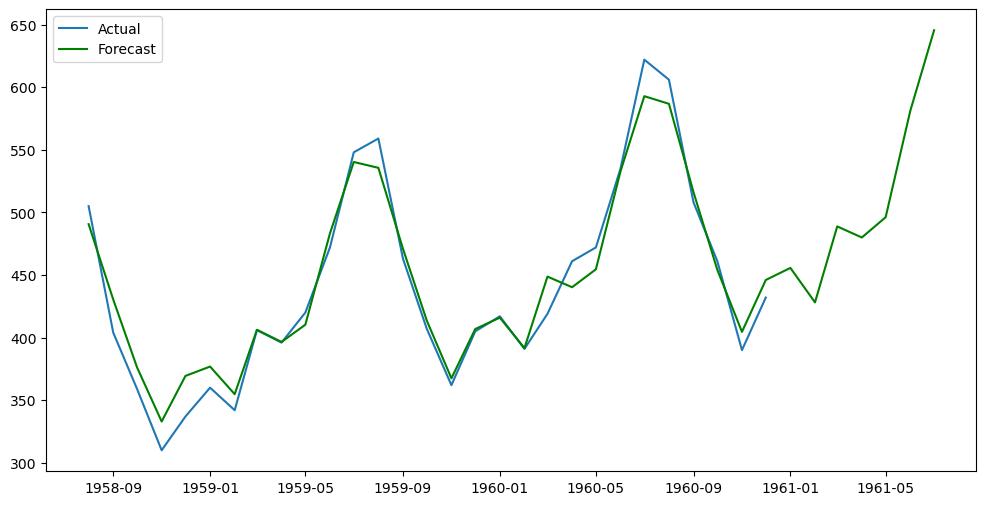

In [29]:
forecast = results.get_forecast(steps=36)

plt.figure(figsize=(12, 6))
plt.plot(test, label='Actual')
plt.plot(forecast.predicted_mean, label='Forecast', color='green')
plt.legend()
plt.show()